In [11]:
import pandas as pd
import networkx as nx

df = pd.read_csv("sankey_2.csv")

G = nx.DiGraph()

In [12]:
for _, row in df.iterrows():
    u = row["source"]
    v = row["target"]

    G.add_edge(
        u,
        v,
        flow=float(row["cabal"]),
        name=row.get("name", "")
    )

In [13]:
for n in G.nodes:
    in_flow = sum(G[u][n]["flow"] for u in G.predecessors(n))
    out_flow = sum(G[n][v]["flow"] for v in G.successors(n))

    G.nodes[n]["in_flow"] = in_flow
    G.nodes[n]["out_flow"] = out_flow
    G.nodes[n]["balance"] = in_flow - out_flow

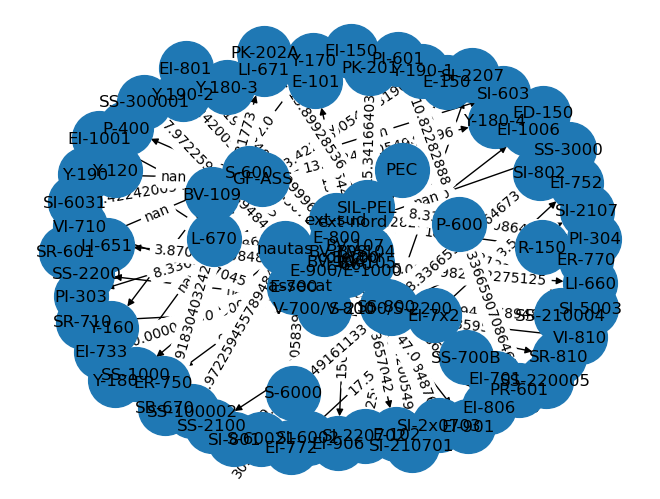

In [14]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G, seed=42)

edge_labels = {(u, v): d["flow"] for u, v, d in G.edges(data=True)}

nx.draw(G, pos, with_labels=True, node_size=1500)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()

In [16]:
import plotly.graph_objects as go

labels = list(set(df["source"]).union(set(df["target"])))
label_map = {l: i for i, l in enumerate(labels)}

source = df["source"].map(label_map)
target = df["target"].map(label_map)
value = df["cabal"]

fig = go.Figure(data=[go.Sankey(
    node=dict(label=labels, pad=15, thickness=20),
    link=dict(source=source, target=target, value=value)
)])

fig.show()